# 1. Get ERA5 Data from Google Cloud Storage

This is new version of ERA5 downloaded to Sockeye. It covers global range and has atmopheric, surface, and static. Stored in Google Cloud Storage. Directories such as https://storage.googleapis.com/gencast/era5_new/2021-06-surface-level.nc.

June valid_time: 2021-06-11T00:00:00.000000000 → 2021-06-30T18:00:00.000000000
July valid_time: 2021-07-01T00:00:00.000000000 → 2021-07-05T18:00:00.000000000
Merged valid_time: 2021-06-11T00:00:00.000000000 → 2021-07-05T18:00:00.000000000


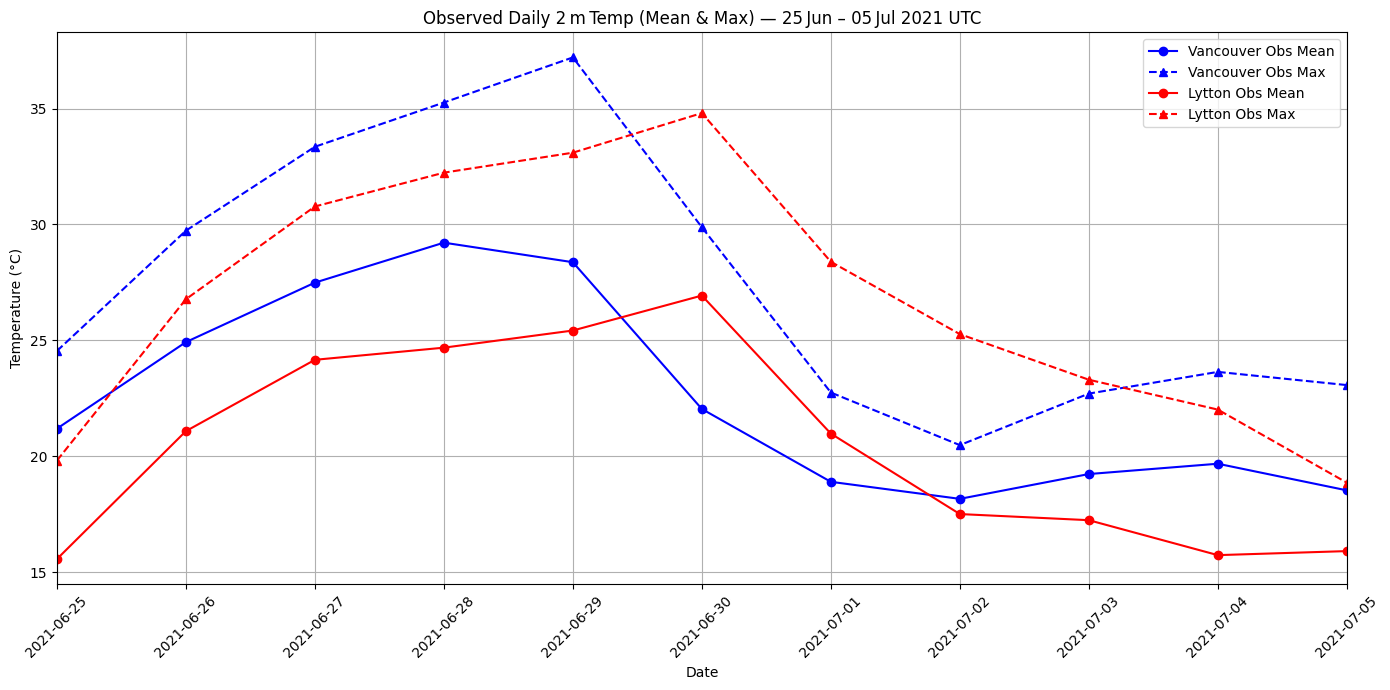

In [20]:
#!/usr/bin/env python
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# —————————————————————
# 1) Copy files locally
# —————————————————————
for month in ["06", "07"]:
    src = f"gs://gencast/era5_new/2021-{month}-surface-level.nc"
    dst = f"/tmp/era5_2021-{month}-surface.nc"
    !gsutil -q cp {src} {dst}

# —————————————————————
# 2) Open each month separately
# —————————————————————
ds_june = xr.open_dataset("/tmp/era5_2021-06-surface.nc", engine="netcdf4")
ds_july = xr.open_dataset("/tmp/era5_2021-07-surface.nc", engine="netcdf4")

print("June valid_time:", ds_june.valid_time.min().values, "→", ds_june.valid_time.max().values)
print("July valid_time:", ds_july.valid_time.min().values, "→", ds_july.valid_time.max().values)

# —————————————————————
# 3) If there is a dummy 'time' dim, drop it
# —————————————————————
for ds_part in (ds_june, ds_july):
    if "time" in ds_part.dims:
        # take the first slice along time, drop that dim
        ds_part = ds_part.isel(time=0, drop=True)
    # reassign back into the proper variable
    if ds_part.valid_time.min().values == ds_june.valid_time.min().values:
        ds_june = ds_part
    else:
        ds_july = ds_part

# —————————————————————
# 4) Concatenate along valid_time
# —————————————————————
ds = xr.concat([ds_june, ds_july], dim="valid_time")
print("Merged valid_time:", ds.valid_time.min().values, "→", ds.valid_time.max().values)
# → should cover 2021‑06‑11 00:00 … 2021‑07‑05 18:00

# —————————————————————
# 5) Define the target daily window: 25 Jun → 05 Jul
# —————————————————————
start_day = np.datetime64("2021-06-25")
end_day   = np.datetime64("2021-07-05")
days = np.arange(start_day,
                 end_day + np.timedelta64(1, "D"),
                 dtype="datetime64[D]")
days_pd = pd.to_datetime(days.astype("datetime64[s]"))

# —————————————————————
# 6) Locate stations on grid
# —————————————————————
stations = {
    "Vancouver": {"lat": 49.2827, "lon": -123.1207},
    "Lytton":    {"lat": 50.2333, "lon": -121.7667},
}
lats = ds.latitude.values
lons = ds.longitude.values
station_idx = {}
for name, c in stations.items():
    lon360 = c["lon"] % 360
    i_lon = int(np.abs(lons - lon360).argmin())
    i_lat = int(np.abs(lats - c["lat"]).argmin())
    station_idx[name] = {"i_lat": i_lat, "i_lon": i_lon}

# —————————————————————
# 7) Extract daily mean & max from ds.valid_time
# —————————————————————
times = ds.valid_time.values.astype("datetime64[h]")
obs = {}
for name, idx in station_idx.items():
    t2m = ds["t2m"].isel(
        latitude = idx["i_lat"],
        longitude= idx["i_lon"],
    ).values - 273.15

    ser = pd.Series(t2m, index=pd.to_datetime(times.astype("datetime64[s]")))
    daily_max  = ser.resample("1D").max().reindex(days_pd)
    daily_mean = ser.resample("1D").mean().reindex(days_pd)

    obs[name] = {
        "daily_max":  daily_max.values,
        "daily_mean": daily_mean.values,
    }

# —————————————————————
# 8) Plot full window
# —————————————————————
plt.figure(figsize=(14, 7))
colors  = {"Vancouver": "blue", "Lytton": "red"}
markers = {"daily_mean": "o", "daily_max": "^"}

for name, stats in obs.items():
    plt.plot(days_pd, stats["daily_mean"],
             color=colors[name],
             marker=markers["daily_mean"],
             linestyle="-",
             label=f"{name} Obs Mean")
    plt.plot(days_pd, stats["daily_max"],
             color=colors[name],
             marker=markers["daily_max"],
             linestyle="--",
             label=f"{name} Obs Max")

plt.title("Observed Daily 2 m Temp (Mean & Max) — 25 Jun – 05 Jul 2021 UTC")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(days_pd, rotation=45)
plt.xlim(days_pd[0], days_pd[-1])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# 2. Get GenCast data from Google Cloud Storage

This data was queried from BigQuery. Forecasted data directly generated by WeatherNext. Lead times were defined as the gap between init_time and forecast_time. Lead times include 1, 3, 7, 10, and 14 days.

## 1. 14 day lead time regrid

In [4]:
#!/usr/bin/env python
import dask.dataframe as dd
import pandas as pd
import xarray as xr

# ─── A) Inspect ERA5 grid ─────────────────────────────────────────────────────
print("=== ERA5 Dataset Info ===")
print(ds)

print("\n=== ERA5 Coordinates ===")
print("Latitude range:", ds.latitude.min().item(), "→", ds.latitude.max().item())
print("Longitude range:", ds.longitude.min().item(), "→", ds.longitude.max().item())

print("\n=== Sample ERA5 data at valid_time[0] ===")
print(ds['t2m'].isel(valid_time=0).isel(latitude=slice(0,5), longitude=slice(0,5)))

# ─── B) Inspect Gencast CSV structure ─────────────────────────────────────────
csv_pattern = "gs://gencast/weathernext/weathernext_bc_heatwave_2021_full_14days/*.csv"
cols = [
    "init_time","forecast_time","geography_polygon_text","geography_text",
    "ensemble_member","total_precipitation_12hr","u_component_100m",
    "v_component_100m","u_component_10m","v_component_10m","temp_2m",
    "mean_sea_level_pressure","sea_surface_temperature"
]

print("\n=== Dask read_csv dtypes ===")
ddf = dd.read_csv(csv_pattern, names=cols, header=None, assume_missing=True)
print(ddf.dtypes)

print("\n=== Sample rows from one file ===")
# grab a tiny sample to inspect geometry
sample = ddf.head(5)
print(sample)

print("\n=== Count non-null polygons ===")
polys = sample['geography_polygon_text'].notnull().sum()
print(f"{polys}/{len(sample)} rows have a geometry string")


=== ERA5 Dataset Info ===
<xarray.Dataset> Size: 2GB
Dimensions:     (valid_time: 100, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 800B 2021-06-11 ... 2021-07-05T18...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 2kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    t2m         (valid_time, latitude, longitude) float32 415MB 274.0 ... 218.2
    u10         (valid_time, latitude, longitude) float32 415MB -0.05392 ... ...
    v10         (valid_time, latitude, longitude) float32 415MB 0.001938 ... ...
    msl         (valid_time, latitude, longitude) float32 415MB 1.011e+05 ......
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             

In [44]:
#!/usr/bin/env python
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs
from shapely import wkt
from scipy.interpolate import griddata

In [7]:
#!/usr/bin/env python
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs
from shapely import wkt
from scipy.interpolate import griddata

# —————————————————————————————————————————————————————
# A) Prepare your ERA5 grid (assume ds is already in memory)
# —————————————————————————————————————————————————————
era5_grid  = ds['t2m'].isel(valid_time=0)
lon_target = era5_grid.longitude.values
lat_target = era5_grid.latitude.values
lon_mesh, lat_mesh = np.meshgrid(lon_target, lat_target)

# station coords
station = 'Lytton'
loc = {'lat':50.2333, 'lon':-121.7667}

# debug window
start_date = '2021-06-25'
end_date   = '2021-06-26 18:00:00'

# —————————————————————————————————————————————————————
# B) List remote CSVs with gcsfs
# —————————————————————————————————————————————————————
fs = gcsfs.GCSFileSystem(project='gencast')
pattern = 'gencast/weathernext/weathernext_bc_heatwave_2021_full_14days/*.csv'
files = fs.glob(pattern)
print("Found", len(files), "files; first 5:", files[:5])
if not files:
    raise SystemExit("No forecast CSVs found under that pattern.")

first = files[0]  # e.g. 'gencast/weathernext/.../0000.csv'
gpath = 'gs://' + first

# —————————————————————————————————————————————————————
# C) Read that CSV into pandas, filter ensemble=0 and time
# —————————————————————————————————————————————————————
cols = [
    "init_time","forecast_time","geography_polygon_text","geography_text",
    "ensemble_member","total_precipitation_12hr","u_component_100m",
    "v_component_100m","u_component_10m","v_component_10m","temp_2m",
    "mean_sea_level_pressure","sea_surface_temperature"
]

df = pd.read_csv(
    fs.open(first),
    names=cols, header=None,
    parse_dates=['forecast_time']
)
df0 = df[df['ensemble_member']==0]
df0 = df0[(df0['forecast_time']>=start_date) & (df0['forecast_time']<=end_date)]
print(f"Ensemble 0 rows in that file in window: {len(df0)}")
if df0.empty:
    raise SystemExit("No rows for ensemble 0 in debug window.")

# pick the first timestamp
ts0 = df0['forecast_time'].iloc[0]
sub = df0[df0['forecast_time']==ts0]
print(f"\nTimestamp {ts0} has {len(sub)} rows.")

# —————————————————————————————————————————————————————
# D) Compute centroids
# —————————————————————————————————————————————————————
sub = sub.copy()
sub['centroid_lon'] = sub['geography_polygon_text'].apply(lambda x: wkt.loads(x).centroid.x)
sub['centroid_lat'] = sub['geography_polygon_text'].apply(lambda x: wkt.loads(x).centroid.y)
print("\nSample centroids + temp_2m (K):")
print(sub[['centroid_lon','centroid_lat','temp_2m']].head())

# —————————————————————————————————————————————————————
# E) Interpolate with griddata
# —————————————————————————————————————————————————————
points = np.column_stack((sub['centroid_lon'], sub['centroid_lat']))
values = sub['temp_2m'].values
grid = griddata(points, values, (lon_mesh, lat_mesh), method='linear')
print(f"\ngrid shape {grid.shape}; % NaN = {np.isnan(grid).mean()*100:.1f}%")
print("grid min/max (K):", np.nanmin(grid), np.nanmax(grid))

# —————————————————————————————————————————————————————
# F) Extract at station
# —————————————————————————————————————————————————————
i_lon = np.abs(lon_target - loc['lon']).argmin()
i_lat = np.abs(lat_target - loc['lat']).argmin()
valK = grid[i_lat, i_lon]
print(f"\nExtracted at {station}: {valK} K → {valK-273.15:.2f} °C")


Found 20 files; first 5: ['gencast/weathernext/weathernext_bc_heatwave_2021_full_14days/000000000000.csv', 'gencast/weathernext/weathernext_bc_heatwave_2021_full_14days/000000000001.csv', 'gencast/weathernext/weathernext_bc_heatwave_2021_full_14days/000000000002.csv', 'gencast/weathernext/weathernext_bc_heatwave_2021_full_14days/000000000003.csv', 'gencast/weathernext/weathernext_bc_heatwave_2021_full_14days/000000000004.csv']
Ensemble 0 rows in that file in window: 25605

Timestamp 2021-06-25 00:00:00+00:00 has 5121 rows.

Sample centroids + temp_2m (K):
   centroid_lon  centroid_lat     temp_2m
0       -128.25         60.50  285.833160
1       -114.75         48.75  288.465576
2       -138.50         55.00  282.796783
3       -138.00         55.25  282.904297
4       -139.00         59.75  278.968781

grid shape (721, 1440); % NaN = 100.0%
grid min/max (K): nan nan

Extracted at Lytton: nan K → nan °C


/var/tmp/ipykernel_28805/269268197.py:80: RuntimeWarning: All-NaN slice encountered
  print("grid min/max (K):", np.nanmin(grid), np.nanmax(grid))


Test with 1 timestamp

In [45]:
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs
from shapely import wkt
from scipy.interpolate import griddata

In [16]:
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs
from shapely import wkt
from scipy.interpolate import griddata

# -----------------------------------------------------------------------------
# A) ERA5 GRID SETUP — assume `ds` is already loaded & concatenated
# -----------------------------------------------------------------------------
era5_grid  = ds['t2m'].isel(valid_time=0)
lon_target = era5_grid.longitude.values
lat_target = era5_grid.latitude.values
lon_mesh, lat_mesh = np.meshgrid(lon_target, lat_target)

# single station for debug
station = "Lytton"
loc     = {"lat": 50.2333, "lon": -121.7667}

# debug window: 2 days × 6h → 8 samples expected
start_date = "2021-06-25"
end_date   = "2021-06-26 18:00:00"

# -----------------------------------------------------------------------------
# B) LIST & READ ONE 6‑HOURLY FORECAST CSV (lead=14day)
# -----------------------------------------------------------------------------
fs      = gcsfs.GCSFileSystem(project="gencast")
pattern = "gencast/weathernext/weathernext_bc_heatwave_2021_full_14day/*.csv"
files   = fs.glob(pattern)
print(f"Found {len(files)} files; testing first:", files[0])
first   = files[0]

cols = [
    "init_time","forecast_time","geography_polygon_text","geography_text",
    "ensemble_member","total_precipitation_12hr","u_component_100m",
    "v_component_100m","u_component_10m","v_component_10m","temp_2m",
    "mean_sea_level_pressure","sea_surface_temperature"
]

df = pd.read_csv(
    fs.open(first),
    names=cols,
    header=None,
    parse_dates=["forecast_time"]
)
# filter for ensemble 0 & debug window
df0 = df[df["ensemble_member"] == 0]
df0 = df0[
    (df0["forecast_time"] >= start_date) &
    (df0["forecast_time"] <= end_date)
]
print("Ensemble 0 rows in window:", len(df0))
if df0.empty:
    raise SystemExit("No rows for ens=0 in window.")

# -----------------------------------------------------------------------------
# C) PICK ONE TIMESTAMP & REGRID → RAW EXTRACTION
# -----------------------------------------------------------------------------
ts0 = df0["forecast_time"].iloc[0]
sub = df0[df0["forecast_time"] == ts0].copy()
print(f"\nTimestamp {ts0} has {len(sub)} polygons → regridding…")

# compute centroids, wrap longitudes into [0,360)
sub["lon0"] = sub["geography_polygon_text"].apply(
    lambda x: wkt.loads(x).centroid.x
)
sub["lat"] = sub["geography_polygon_text"].apply(
    lambda x: wkt.loads(x).centroid.y
)
sub["lon"] = sub["lon0"] % 360

print("\nSample centroids + temp_2m (K):")
print(sub[["lon","lat","temp_2m"]].head())

# interpolate to ERA5 grid
pts  = np.column_stack((sub["lon"], sub["lat"]))
vals = sub["temp_2m"].values
grid = griddata(pts, vals, (lon_mesh, lat_mesh), method="linear")

print(f"\ngrid shape: {grid.shape}")
print("%% NaN in grid:", np.isnan(grid).mean()*100)
print("grid K min/max:", np.nanmin(grid), np.nanmax(grid))

# extract at station
i_lon = np.abs(lon_target - (loc["lon"]%360)).argmin()
i_lat = np.abs(lat_target - loc["lat"]).argmin()
tempK = grid[i_lat, i_lon]
print(f"\nRaw extraction at {station}: {tempK:.3f} K → {tempK-273.15:.2f} °C")


# -----------------------------------------------------------------------------
# D) LOAD YOUR SAVED RAW CSV & CHECK DAILY AGGREGATION
# -----------------------------------------------------------------------------
raw_path = "heatNN/script/ensemble_outputs/14day/raw/ens0_Lytton_raw.csv"
print("\nLoading raw CSV:", raw_path)
df_raw = pd.read_csv(raw_path, parse_dates=["forecast_time"])
print("Raw CSV rows:", len(df_raw), "(expect 8 for this debug window)")
print(df_raw.head())

# find which temp column you have
temp_col = [c for c in df_raw.columns if c.startswith("temp")][0]
print("Using temperature column:", temp_col)

# compute daily mean & max
df_raw["date"] = df_raw["forecast_time"].dt.floor("D")
daily = (
    df_raw
      .groupby("date")[temp_col]
      .agg(daily_avg="mean", daily_max="max")
      .reset_index()
)
print("\nDaily aggregated (2 rows expected):")
print(daily)


Found 20 files; testing first: gencast/weathernext/weathernext_bc_heatwave_2021_full_14day/000000000000.csv
Ensemble 0 rows in window: 24570

Timestamp 2021-06-25 00:00:00+00:00 has 4914 polygons → regridding…

Sample centroids + temp_2m (K):
      lon    lat     temp_2m
0  221.00  50.50  283.507629
1  244.00  49.25  287.650848
2  236.50  60.50  293.228333
3  246.00  49.00  286.461029
4  226.75  60.00  286.370789

grid shape: (721, 1440)
%% NaN in grid: 99.50888041300662
grid K min/max: 270.56231689453125 300.1549072265625

Raw extraction at Lytton: 286.125 K → 12.98 °C

Loading raw CSV: heatNN/script/ensemble_outputs/14day/raw/ens0_Lytton_raw.csv
Raw CSV rows: 41 (expect 8 for this debug window)
              forecast_time  temp_2m_C
0 2021-06-25 00:00:00+00:00  12.975092
1 2021-06-25 06:00:00+00:00  11.274103
2 2021-06-25 12:00:00+00:00   8.630334
3 2021-06-25 18:00:00+00:00  20.943353
4 2021-06-26 00:00:00+00:00  24.331201
Using temperature column: temp_2m_C

Daily aggregated (2 row

All timestamps for 14-day lead

In [46]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import dask.dataframe as dd
import xarray as xr
import gcsfs
from shapely import wkt
from scipy.interpolate import griddata
from tqdm import tqdm


In [17]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import dask.dataframe as dd
import xarray as xr
import gcsfs
from shapely import wkt
from scipy.interpolate import griddata
from tqdm import tqdm

# -----------------------------------------------------------------------------
# (A) ERA5 GRID SETUP — assume `ds` is already loaded & concatenated
# -----------------------------------------------------------------------------
era5_grid  = ds['t2m'].isel(valid_time=0)
lon_target = era5_grid.longitude.values   # 0…359.75
lat_target = era5_grid.latitude.values    # 90…-90
lon_mesh, lat_mesh = np.meshgrid(lon_target, lat_target)

# station definitions
stations = {
    "Vancouver": {"lat": 49.2827, "lon": -123.1207},
    "Lytton":    {"lat": 50.2333, "lon": -121.7667},
}

# build daily index for 2021‑06‑25 … 2021‑07‑05
start_day = np.datetime64("2021-06-25")
end_day   = np.datetime64("2021-07-05")
days      = np.arange(start_day, end_day + np.timedelta64(1, "D"),
                      dtype="datetime64[D]")
days_pd   = pd.to_datetime(days.astype("datetime64[s]"))

# -----------------------------------------------------------------------------
# (B) READ ALL 6‑HOURLY FORECAST CSVs FOR 14‑DAY LEAD
# -----------------------------------------------------------------------------
# NOTE: include "gs://" prefix and pass storage_options so Dask can talk to GCS
pattern = "gs://gencast/weathernext/weathernext_bc_heatwave_2021_full_14day/*.csv"
storage_options = {"token": "google_default"}  # or your GCP credentials

# only need these columns
usecols = ["forecast_time","geography_polygon_text","ensemble_member","temp_2m"]

ddf = dd.read_csv(
    pattern,
    storage_options=storage_options,
    names=[
        "init_time","forecast_time","geography_polygon_text","geography_text",
        "ensemble_member","total_precipitation_12hr","u_component_100m",
        "v_component_100m","u_component_10m","v_component_10m","temp_2m",
        "mean_sea_level_pressure","sea_surface_temperature"
    ],
    usecols=usecols,
    header=None,
    assume_missing=True
)

# parse times and filter our window
ddf["forecast_time"] = dd.to_datetime(ddf["forecast_time"], errors="coerce")
ddf = ddf[
    (ddf["forecast_time"] >= "2021-06-25")
  & (ddf["forecast_time"] <= "2021-07-05")
]

# -----------------------------------------------------------------------------
# (C) REGRIDDING HELPER
# -----------------------------------------------------------------------------
def regrid_to_era5(subdf):
    df = subdf.copy()
    # centroids
    df["lon0"] = df["geography_polygon_text"].apply(
        lambda x: wkt.loads(x).centroid.x
    )
    df["lat"] = df["geography_polygon_text"].apply(
        lambda x: wkt.loads(x).centroid.y
    )
    # wrap longitudes into [0,360)
    df["lon"] = df["lon0"] % 360

    pts = np.column_stack((df["lon"], df["lat"]))
    vals = df["temp_2m"].values
    return griddata(pts, vals, (lon_mesh, lat_mesh), method="linear")

# -----------------------------------------------------------------------------
# (D) PROCESS ENSEMBLE MEMBERS → SAVE RAW & DAILY CSVs (but skip already‐done)
# -----------------------------------------------------------------------------
base_dir  = "heatNN/script/ensemble_outputs/14day"
raw_dir   = os.path.join(base_dir, "raw")
daily_dir = os.path.join(base_dir, "daily")
os.makedirs(raw_dir,  exist_ok=True)
os.makedirs(daily_dir, exist_ok=True)

for ens in tqdm(range(50), desc="Ensemble members"):
    # check existing raw files
    raw_paths = {
        name: os.path.join(raw_dir,  f"ens{ens}_{name}_raw.csv")
        for name in stations
    }
    daily_paths = {
        name: os.path.join(daily_dir, f"ens{ens}_{name}_daily.csv")
        for name in stations
    }

    # if every raw CSV exists and is non-empty, assume already done → skip
    all_done = all(
        os.path.exists(raw_paths[name]) and os.path.getsize(raw_paths[name]) > 0
        for name in stations
    )
    if all_done:
        continue

    # otherwise load this member’s data and regrid
    pdf = ddf[ddf["ensemble_member"] == ens].compute()
    if pdf.empty:
        # still write empty files so downstream combine sees them
        for name in stations:
            pd.DataFrame(columns=["forecast_time","temp_2m_C"])\
              .to_csv(raw_paths[name], index=False)
            pd.DataFrame({
                "date": days_pd,
                "daily_avg": np.nan,
                "daily_max": np.nan
            }).to_csv(daily_paths[name], index=False)
        continue

    raw_data = {name: [] for name in stations}
    for ts in sorted(pdf["forecast_time"].unique()):
        sub  = pdf[pdf["forecast_time"] == ts]
        grid = regrid_to_era5(sub)

        for name, loc in stations.items():
            i_lon = np.abs(lon_target - (loc["lon"] % 360)).argmin()
            i_lat = np.abs(lat_target -  loc["lat"]       ).argmin()
            tmpK  = grid[i_lat, i_lon]
            if np.isnan(tmpK):
                continue
            raw_data[name].append((ts, tmpK - 273.15))

    # now write out raw & daily for each station
    for name in stations:
        # ---- RAW CSV ----
        df_raw = pd.DataFrame(raw_data[name], columns=["forecast_time","temp_2m_C"])
        df_raw.to_csv(raw_paths[name], index=False)

        # ---- DAILY CSV ----
        df_raw["date"] = pd.to_datetime(df_raw["forecast_time"]).dt.floor("D")
        daily = (
            df_raw.groupby("date")["temp_2m_C"]
                  .agg(daily_avg="mean", daily_max="max")
                  .reindex(days_pd)
                  .reset_index()
        )
        daily.to_csv(daily_paths[name], index=False)

Ensemble members: 100%|██████████| 50/50 [30:04<00:00, 36.09s/it]


In [28]:
cd heatNN/script

/home/jupyter/heatNN/script


/opt/conda/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [34]:
#!/usr/bin/env python3
import os
import re
import glob
import warnings
import pandas as pd
import numpy as np

# ─── Silence warnings ─────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")

# ─── Configuration ────────────────────────────────────────────────────────────
raw_dir   = "heatNN/script/ensemble_outputs/14day/raw"
daily_dir = "heatNN/script/ensemble_outputs/14day/daily"
os.makedirs(daily_dir, exist_ok=True)

# full date index (naive datetimes)
start_day = "2021-06-25"
end_day   = "2021-07-05"
all_days  = pd.date_range(start_day, end_day, freq="D")

# ─── Find all raw CSVs ───────────────────────────────────────────────────────
pattern   = os.path.join(raw_dir, "*_*_raw.csv")
raw_files = glob.glob(pattern)
print(f"Found {len(raw_files)} raw CSVs, regenerating missing daily files…")

# ─── Loop over each ensemble × station raw file ──────────────────────────────
for raw_path in raw_files:
    fn = os.path.basename(raw_path)
    m = re.match(r"ens(\d+)_(\w+)_raw\.csv", fn)
    if not m:
        continue
    ens_id, station = int(m.group(1)), m.group(2)
    daily_fname = fn.replace("_raw.csv", "_daily.csv")
    daily_path  = os.path.join(daily_dir, daily_fname)

    # skip if daily already has any non‐NaN
    if os.path.exists(daily_path):
        df_exist = pd.read_csv(daily_path)
        if df_exist[['daily_avg','daily_max']].notna().any().any():
            continue

    # load raw
    df = pd.read_csv(raw_path, parse_dates=["forecast_time"])
    # aggregate
    if df.empty:
        daily = pd.DataFrame({
            "date":            all_days,
            "daily_avg":       np.nan,
            "daily_max":       np.nan,
            "ensemble_member": ens_id
        })
    else:
        df["date"] = df["forecast_time"].dt.normalize()
        agg = (
            df.groupby("date")["temp_2m_C"]
              .agg(daily_avg="mean", daily_max="max")
              .reset_index()
        )
        if pd.api.types.is_datetime64tz_dtype(agg["date"].dtype):
            agg["date"] = agg["date"].dt.tz_convert(None)
        daily = (
            pd.DataFrame({"date": all_days})
              .merge(agg, on="date", how="left")
        )
        daily["ensemble_member"] = ens_id

    daily.to_csv(daily_path, index=False)
    print(f"  → regenerated {daily_fname}")

print("Done.")


Found 100 raw CSVs, regenerating missing daily files…
Done.


Combine and Upload to Cloud Storage

In [36]:
#!/usr/bin/env python3
import os
import glob
import logging
import pandas as pd
from google.cloud import storage

# —————————————————————————————————————————————————————————————
# CONFIG
# —————————————————————————————————————————————————————————————

DAILY_DIR    = "heatNN/script/ensemble_outputs/14day/daily"

# Where to write your two combined CSVs locally:
COMBINED_DIR = "combined_outputs"
os.makedirs(COMBINED_DIR, exist_ok=True)

# GCS target
BUCKET_NAME = "gencast"
GCS_PREFIX  = "daily_forecast_14day"

# Stations to process
STATIONS = ["vancouver", "lytton"]

# Minimal logging
logging.basicConfig(level=logging.INFO, format="%(message)s")
# —————————————————————————————————————————————————————————————
# COMBINE & UPLOAD
# —————————————————————————————————————————————————————————————
client = storage.Client()

for station in STATIONS:
    pattern = os.path.join(DAILY_DIR, f"ens*_{station.capitalize()}_daily.csv")
    files = glob.glob(pattern)
    if not files:
        logging.warning(f"No daily files for `{station}` (tried `{pattern}`)")
        continue

    dfs = []
    for fp in files:
        df = pd.read_csv(fp, parse_dates=["date"])
        ens = int(os.path.basename(fp).split("_")[0].lstrip("ens"))
        df["ensemble_member"] = ens
        dfs.append(df)

    combined = (
        pd.concat(dfs, ignore_index=True)
          .loc[:, ["date","ensemble_member","daily_avg","daily_max"]]
    )

    out_local = os.path.join(COMBINED_DIR, f"{station}_daily_forecast_14day.csv")
    combined.to_csv(out_local, index=False)
    logging.info(f"Wrote combined `{station}` → {out_local}")

    # upload
    blob_path = f"{GCS_PREFIX}/{station}_daily_forecast_14day.csv"
    bucket = client.bucket(BUCKET_NAME)
    bucket.blob(blob_path).upload_from_filename(out_local)
    logging.info(f"Uploaded → gs://{BUCKET_NAME}/{blob_path}")

logging.info("✅ All done.")


Wrote combined `vancouver` → combined_outputs/vancouver_daily_forecast_14day.csv
Uploaded → gs://gencast/daily_forecast_14day/vancouver_daily_forecast_14day.csv
Wrote combined `lytton` → combined_outputs/lytton_daily_forecast_14day.csv
Uploaded → gs://gencast/daily_forecast_14day/lytton_daily_forecast_14day.csv
✅ All done.


In [37]:
combined.head()

,date,ensemble_member,daily_avg,daily_max
0,2021-06-25,20,9.910509,13.630792
1,2021-06-26,20,10.884683,14.789178
2,2021-06-27,20,13.306551,24.003870
3,2021-06-28,20,16.034387,26.056573
4,2021-06-29,20,13.260408,26.922357


 ## 2. Regrid 10 day lead time

In [43]:
#!/usr/bin/env python3
import os
import glob
import numpy as np
import pandas as pd
import dask.dataframe as dd
import xarray as xr
import gcsfs
from shapely import wkt
from scipy.interpolate import griddata
from tqdm import tqdm
from google.cloud import storage

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------
LEAD_DAYS   = 10                     # ← change this to 7, 14, etc.
LEAD_STR    = f"{LEAD_DAYS}day"      # e.g. "10day"
GCS_BUCKET  = "gencast/weathernext"
GCS_WEATH  = f"gs://{GCS_BUCKET}/weathernext_bc_heatwave_2021_full_{LEAD_STR}"
GCS_OUT    = f"daily_forecast_{LEAD_STR}"

# Local directories
BASE_DIR     = f"ensemble_outputs/{LEAD_STR}"
RAW_DIR      = os.path.join(BASE_DIR, "raw")
DAILY_DIR    = os.path.join(BASE_DIR, "daily")
COMBINED_DIR = "combined_outputs"
os.makedirs(RAW_DIR,     exist_ok=True)
os.makedirs(DAILY_DIR,   exist_ok=True)
os.makedirs(COMBINED_DIR, exist_ok=True)

# ERA5 files (assumes you have June/July surface-level .nc files)
ERA5_FILES = [
    "/tmp/era5_2021-06-surface.nc",
    "/tmp/era5_2021-07-surface.nc",
]

# Station definitions
STATIONS = {
    "Vancouver": {"lat": 49.2827, "lon": -123.1207},
    "Lytton":    {"lat": 50.2333, "lon": -121.7667},
}

# Date range to evaluate
START = "2021-06-25"
END   = "2021-07-05"
DAYS  = pd.date_range(START, END, freq="D")

# ──────────────────────────────────────────────────────────────────────────────
# A) LOAD & CONCAT ERA5 (once)
# ──────────────────────────────────────────────────────────────────────────────
ds_list = [xr.open_dataset(f, engine="netcdf4") for f in ERA5_FILES]
ds      = xr.concat(ds_list, dim="valid_time")

era5_grid  = ds["t2m"].isel(valid_time=0)
lon_target = era5_grid.longitude.values
lat_target = era5_grid.latitude.values
lon_mesh, lat_mesh = np.meshgrid(lon_target, lat_target)

# ──────────────────────────────────────────────────────────────────────────────
# B) LOAD & FILTER GENCAST 6‑HOURLY CSVs WITH DASK
# ──────────────────────────────────────────────────────────────────────────────
pattern = f"{GCS_WEATH}/*.csv"
storage_opts = {"token": "google_default"}

cols_to_use = ["forecast_time","geography_polygon_text","ensemble_member","temp_2m"]
ddf = dd.read_csv(
    pattern,
    storage_options=storage_opts,
    names=[
        "init_time","forecast_time","geography_polygon_text","geography_text",
        "ensemble_member","total_precipitation_12hr","u_component_100m",
        "v_component_100m","u_component_10m","v_component_10m","temp_2m",
        "mean_sea_level_pressure","sea_surface_temperature"
    ],
    usecols=cols_to_use,
    header=None,
    assume_missing=True
)
ddf["forecast_time"] = dd.to_datetime(ddf["forecast_time"], errors="coerce")
ddf = ddf[(ddf["forecast_time"] >= START) & (ddf["forecast_time"] <= END)]

# ──────────────────────────────────────────────────────────────────────────────
# C) REGRIDDING HELPER
# ──────────────────────────────────────────────────────────────────────────────
def regrid_to_era5(subdf):
    df = subdf.copy()
    df["lon0"] = df["geography_polygon_text"].apply(lambda x: wkt.loads(x).centroid.x)
    df["lat"]  = df["geography_polygon_text"].apply(lambda x: wkt.loads(x).centroid.y)
    df["lon"]  = df["lon0"] % 360
    pts = np.column_stack((df["lon"], df["lat"]))
    vals = df["temp_2m"].values
    return griddata(pts, vals, (lon_mesh, lat_mesh), method="linear")

# ──────────────────────────────────────────────────────────────────────────────
# D) PROCESS ENSEMBLES → SAVE RAW & DAILY CSVs
# ──────────────────────────────────────────────────────────────────────────────
for ens in tqdm(range(50), desc=f"{LEAD_DAYS}-day ensembles"):
    pdf = ddf[ddf["ensemble_member"] == ens].compute()
    # if no data, write empty placeholders
    if pdf.empty:
        for name in STATIONS:
            pd.DataFrame(columns=["forecast_time","temp_2m_C"])\
              .to_csv(f"{RAW_DIR}/ens{ens}_{name}_raw.csv", index=False)
            pd.DataFrame({"date": DAYS, "daily_avg": np.nan, "daily_max": np.nan})\
              .to_csv(f"{DAILY_DIR}/ens{ens}_{name}_daily.csv", index=False)
        continue

    # build raw 6‑h data
    raw_data = {name: [] for name in STATIONS}
    for ts in sorted(pdf["forecast_time"].unique()):
        sub  = pdf[pdf["forecast_time"] == ts]
        grid = regrid_to_era5(sub)
        for name, loc in STATIONS.items():
            i_lon = np.abs(lon_target - (loc["lon"] % 360)).argmin()
            i_lat = np.abs(lat_target - loc["lat"]    ).argmin()
            tmpK  = grid[i_lat, i_lon]
            if not np.isnan(tmpK):
                raw_data[name].append((ts, tmpK - 273.15))

    # save per‑station
    for name in STATIONS:
        df_raw = pd.DataFrame(raw_data[name], columns=["forecast_time","temp_2m_C"])
        df_raw.to_csv(f"{RAW_DIR}/ens{ens}_{name}_raw.csv", index=False)

        if df_raw.empty:
            df_daily = pd.DataFrame({"date": DAYS, "daily_avg": np.nan, "daily_max": np.nan})
        else:
            df_raw["date"] = pd.to_datetime(df_raw["forecast_time"]).dt.normalize()
            agg = (
                df_raw
                .groupby("date")["temp_2m_C"]
                .agg(daily_avg="mean", daily_max="max")
            )
            df_daily = agg.reindex(DAYS).reset_index()

        df_daily.to_csv(f"{DAILY_DIR}/ens{ens}_{name}_daily.csv", index=False)

# ──────────────────────────────────────────────────────────────────────────────
# E) COMBINE DAILY FILES & UPLOAD JUST TWO CSVs TO GCS
# ──────────────────────────────────────────────────────────────────────────────
client = storage.Client()
bucket = client.bucket(GCS_BUCKET)

for station in ["vancouver", "lytton"]:
    files = glob.glob(f"{DAILY_DIR}/ens*_{station.capitalize()}_daily.csv")
    dfs   = []
    for fp in files:
        tmp = pd.read_csv(fp, parse_dates=["date"])
        ens = int(os.path.basename(fp).split("_")[0].lstrip("ens"))
        tmp["ensemble_member"] = ens
        dfs.append(tmp)
    combined = (
        pd.concat(dfs, ignore_index=True)
          .loc[:, ["date","ensemble_member","daily_avg","daily_max"]]
    )
    local_out = f"{COMBINED_DIR}/{station}_daily_forecast_{LEAD_STR}.csv"
    combined.to_csv(local_out, index=False)

    blob = bucket.blob(f"{GCS_OUT}/{station}_daily_forecast_{LEAD_STR}.csv")
    blob.upload_from_filename(local_out)

print(f"✅ Completed {LEAD_DAYS}-day pipeline and uploaded two CSVs.")


Found 100 raw CSVs in 'heatNN/script/ensemble_outputs/10day/raw'
✅ Rebuilt 100 daily CSVs → 'heatNN/script/ensemble_outputs/10day/daily'
🏷  Combined → combined_outputs/vancouver_daily_forecast_10day.csv


NotFound: 404 POST https://storage.googleapis.com/upload/storage/v1/b/gencast/weathernext/o?uploadType=multipart: Not Found: ('Request failed with status code', 404, 'Expected one of', <HTTPStatus.OK: 200>)

Daily CSVs only have date, no value in the temperature columns. Raw CSVs have values. CODE below generate the daily csvs.

In [42]:
ds.head()

<xarray.Dataset> Size: 2kB
Dimensions:     (valid_time: 5, latitude: 5, longitude: 5)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 40B 2021-06-11 ... 2021-06-12
  * latitude    (latitude) float64 40B 90.0 89.75 89.5 89.25 89.0
  * longitude   (longitude) float64 40B 0.0 0.25 0.5 0.75 1.0
    expver      (valid_time) <U4 80B '0001' '0001' '0001' '0001' '0001'
Data variables:
    t2m         (valid_time, latitude, longitude) float32 500B 274.0 ... 273.7
    u10         (valid_time, latitude, longitude) float32 500B -0.05392 ... -...
    v10         (valid_time, latitude, longitude) float32 500B 0.001938 ... -...
    msl         (valid_time, latitude, longitude) float32 500B 1.011e+05 ... ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-30T22:46 GRIB to CDM+CF via cfgrib-0.9.1...

In [48]:
#!/usr/bin/env python3
import warnings
warnings.filterwarnings("ignore")

import os, glob
import numpy as np
import pandas as pd
from google.cloud import storage

# ─── CONFIG ────────────────────────────────────────────────────────────────────
LEAD        = 10
START_DATE  = "2021-06-25"
END_DATE    = "2021-07-05"

RAW_DIR     = f"heatNN/script/ensemble_outputs/{LEAD}day/raw"
DAILY_DIR   = f"heatNN/script/ensemble_outputs/{LEAD}day/daily"
COMB_DIR    = "combined_outputs"

GCS_BUCKET  = "gencast"                             # your bucket
GCS_PREFIX  = f"daily_forecast_{LEAD}day"            # <-- no more "weathernext/"

os.makedirs(DAILY_DIR, exist_ok=True)
os.makedirs(COMB_DIR,  exist_ok=True)

ALL_DAYS = pd.date_range(START_DATE, END_DATE, freq="D")

# ─── STEP 1: REBUILD per‑ensemble DAILY CSVs ────────────────────────────────────
raw_files = glob.glob(os.path.join(RAW_DIR, "ens*_*_raw.csv"))
print(f"Found {len(raw_files)} raw CSVs in {RAW_DIR!r}")
rebuilt = 0

for raw_fp in raw_files:
    df      = pd.read_csv(raw_fp, parse_dates=["forecast_time"])
    fname   = os.path.basename(raw_fp)
    ens     = int(fname.split("_")[0].lstrip("ens"))
    station = fname.split("_")[-2]

    # strip tz if present
    if pd.api.types.is_datetime64tz_dtype(df["forecast_time"].dtype):
        df["forecast_time"] = df["forecast_time"].dt.tz_convert(None)

    if not df.empty:
        df["date"] = df["forecast_time"].dt.normalize()
        agg = (
            df
            .groupby("date")["temp_2m_C"]
            .agg(daily_avg="mean", daily_max="max")
        )
        daily = agg.reindex(ALL_DAYS).rename_axis("date").reset_index()
    else:
        daily = pd.DataFrame({
            "date":      ALL_DAYS,
            "daily_avg": np.nan,
            "daily_max": np.nan
        })

    out_fp = os.path.join(DAILY_DIR, f"ens{ens}_{station}_daily.csv")
    daily.to_csv(out_fp, index=False)
    rebuilt += 1

print(f"✅ Rebuilt {rebuilt} daily CSVs → {DAILY_DIR!r}")

# ─── STEP 2: COMBINE & UPLOAD ───────────────────────────────────────────────────
client = storage.Client()
bucket = client.bucket(GCS_BUCKET)

for station in ["Vancouver", "Lytton"]:
    pattern = os.path.join(DAILY_DIR, f"ens*_{station}_daily.csv")
    files = glob.glob(pattern)
    if not files:
        print(f"⚠️  No daily CSVs found for {station!r} under {DAILY_DIR!r}")
        continue

    dfs = []
    for fp in files:
        tmp = pd.read_csv(fp, parse_dates=["date"])
        ens = int(os.path.basename(fp).split("_")[0].lstrip("ens"))
        tmp["ensemble_member"] = ens
        dfs.append(tmp[["date","ensemble_member","daily_avg","daily_max"]])

    combined = pd.concat(dfs, ignore_index=True)
    combined = combined.sort_values(["ensemble_member","date"])

    local_out = os.path.join(COMB_DIR, f"{station.lower()}_daily_forecast_{LEAD}day.csv")
    combined.to_csv(local_out, index=False)
    print(f"🏷  Combined → {local_out}")

    blob = bucket.blob(f"{GCS_PREFIX}/{os.path.basename(local_out)}")
    blob.upload_from_filename(local_out)
    print(f"🚀 Uploaded → gs://{GCS_BUCKET}/{GCS_PREFIX}/{os.path.basename(local_out)}")

print("🎉 All done for lead time:", LEAD, "day.")


Found 100 raw CSVs in 'heatNN/script/ensemble_outputs/10day/raw'
✅ Rebuilt 100 daily CSVs → 'heatNN/script/ensemble_outputs/10day/daily'
🏷  Combined → combined_outputs/vancouver_daily_forecast_10day.csv
🚀 Uploaded → gs://gencast/daily_forecast_10day/vancouver_daily_forecast_10day.csv
🏷  Combined → combined_outputs/lytton_daily_forecast_10day.csv
🚀 Uploaded → gs://gencast/daily_forecast_10day/lytton_daily_forecast_10day.csv
🎉 All done for lead time: 10 day.


## 3. Regrid 7, 3, 1 day lead time

In [ ]:
#!/usr/bin/env python3
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import numpy as np
import pandas as pd
import dask.dataframe as dd
import xarray as xr
import gcsfs
from shapely import wkt
from scipy.interpolate import griddata
from tqdm import tqdm
from google.cloud import storage

# ─── CONFIGURATION ─────────────────────────────────────────────────────────────
#  ERA5 dataset (assumed already loaded)
#  (Make sure you've concatenated June & July into `ds` with dims valid_time,latitude,longitude)
#    ds = xr.concat([...], dim="valid_time")

#  Lead times to process:
LEAD_TIMES = [1, 3, 7, 10, 14]

#  Forecast window:
START_DATE = "2021-06-25"
END_DATE   = "2021-07-05"
ALL_DAYS   = pd.date_range(START_DATE, END_DATE, freq="D")

#  Local directories:
BASE_LOCAL   = "heatNN/script/ensemble_outputs"
COMBINED_DIR = "combined_outputs"
os.makedirs(COMBINED_DIR, exist_ok=True)

#  GCS for combined:
GCS_BUCKET = "gencast"
#  (combined → gs://gencast/daily_forecast_{lead}day/{station}_daily_forecast_{lead}day.csv)

#  Prepare ERA5 grid for regridding:
era5_grid  = ds["t2m"].isel(valid_time=0)
lon_target = era5_grid.longitude.values
lat_target = era5_grid.latitude.values
lon_mesh, lat_mesh = np.meshgrid(lon_target, lat_target)

#  Stations:
STATIONS = {
    "Vancouver": {"lat": 49.2827, "lon": -123.1207},
    "Lytton":    {"lat": 50.2333, "lon": -121.7667},
}

#  GCSFS for reading forecast CSVs:
gcs = gcsfs.GCSFileSystem(project="gencast")

#  Helper: regrid one timestamp’s scattered forecasts → ERA5 mesh
def regrid_to_era5(df):
    df = df.copy()
    df["lon0"] = df["geography_polygon_text"].apply(lambda x: wkt.loads(x).centroid.x)
    df["lat"]  = df["geography_polygon_text"].apply(lambda x: wkt.loads(x).centroid.y)
    pts = np.column_stack((df["lon0"] % 360, df["lat"]))
    vals = df["temp_2m"].values
    return griddata(pts, vals, (lon_mesh, lat_mesh), method="linear")

#  Initialize GCS client for uploads:
gcs_client = storage.Client()
gcs_bucket = gcs_client.bucket(GCS_BUCKET)

for LEAD in LEAD_TIMES:
    print(f"\n\n===== LEAD TIME: {LEAD} day =====")

    # 1) READ & FILTER ALL 6‑HOURLY FORECASTS VIA DASK
    pattern = f"gs://gencast/weathernext/weathernext_bc_heatwave_2021_full_{LEAD}day/*.csv"
    ddf = dd.read_csv(
        pattern,
        storage_options={"token":"google_default"},
        names=[
            "init_time","forecast_time","geography_polygon_text","geography_text",
            "ensemble_member","total_precipitation_12hr","u_component_100m",
            "v_component_100m","u_component_10m","v_component_10m","temp_2m",
            "mean_sea_level_pressure","sea_surface_temperature"
        ],
        usecols=["forecast_time","geography_polygon_text","ensemble_member","temp_2m"],
        header=None, assume_missing=True
    )
    ddf["forecast_time"] = dd.to_datetime(ddf["forecast_time"], errors="coerce")
    ddf = ddf[
        (ddf["forecast_time"] >= START_DATE)
      & (ddf["forecast_time"] <= END_DATE)
    ]

    # 2) DIRECTORIES FOR THIS LEAD
    raw_dir   = os.path.join(BASE_LOCAL, f"{LEAD}day", "raw")
    daily_dir = os.path.join(BASE_LOCAL, f"{LEAD}day", "daily")
    os.makedirs(raw_dir,  exist_ok=True)
    os.makedirs(daily_dir, exist_ok=True)

    # 3) LOOP OVER ENSEMBLES → EXTRACT & REGRID
    for ens in tqdm(range(50), desc=f"Regridding {LEAD}d"):
        raw_path_ok = True
        # if raw already exists and non‐empty, skip regridding:
        for st in STATIONS:
            p = os.path.join(raw_dir, f"ens{ens}_{st}_raw.csv")
            if not (os.path.exists(p) and os.path.getsize(p)>0):
                raw_path_ok = False
                break
        if raw_path_ok:
            continue

        pdf = ddf[ddf["ensemble_member"] == ens].compute()
        # prepare per‐station raw lists:
        raw_data = {st: [] for st in STATIONS}

        if not pdf.empty:
            for ts in sorted(pdf["forecast_time"].unique()):
                sub = pdf[pdf["forecast_time"] == ts]
                grid = regrid_to_era5(sub)
                for st, loc in STATIONS.items():
                    i_lon = np.abs(lon_target - (loc["lon"] % 360)).argmin()
                    i_lat = np.abs(lat_target -  loc["lat"]     ).argmin()
                    tmpK  = grid[i_lat, i_lon]
                    if not np.isnan(tmpK):
                        raw_data[st].append((ts, tmpK - 273.15))

        # write out raw & daily for each station
        for st in STATIONS:
            df_raw = pd.DataFrame(raw_data[st], columns=["forecast_time","temp_2m_C"])
            raw_fp = os.path.join(raw_dir, f"ens{ens}_{st}_raw.csv")
            df_raw.to_csv(raw_fp, index=False)

            # daily aggregation
            if not df_raw.empty:
                df_raw["date"] = pd.to_datetime(df_raw["forecast_time"]).dt.normalize()
                agg = (
                    df_raw
                    .groupby("date")["temp_2m_C"]
                    .agg(daily_avg="mean", daily_max="max")
                )
                daily = agg.reindex(ALL_DAYS).rename_axis("date").reset_index()
            else:
                daily = pd.DataFrame({
                    "date":      ALL_DAYS,
                    "daily_avg": np.nan,
                    "daily_max": np.nan
                })

            daily_fp = os.path.join(daily_dir, f"ens{ens}_{st}_daily.csv")
            daily.to_csv(daily_fp, index=False)

    print(f" → Raw & daily CSVs ready in {daily_dir!r}")

    # 4) COMBINE & UPLOAD
    prefix = f"daily_forecast_{LEAD}day"
    for st in STATIONS:
        files = glob.glob(os.path.join(daily_dir, f"ens*_{st}_daily.csv"))
        dfs   = []
        for fp in files:
            tmp = pd.read_csv(fp, parse_dates=["date"])
            ens_id = int(os.path.basename(fp).split("_")[0].lstrip("ens"))
            tmp["ensemble_member"] = ens_id
            dfs.append(tmp[["date","ensemble_member","daily_avg","daily_max"]])

        combined = pd.concat(dfs, ignore_index=True)
        combined = combined.sort_values(["ensemble_member","date"])
        local_out = os.path.join(
            COMBINED_DIR,
            f"{st.lower()}_daily_forecast_{LEAD}day.csv"
        )
        combined.to_csv(local_out, index=False)
        print(f"  • Combined → {local_out}")

        blob = gcs_bucket.blob(f"{prefix}/{os.path.basename(local_out)}")
        blob.upload_from_filename(local_out)
        print(f"  • Uploaded → gs://{GCS_BUCKET}/{prefix}/{os.path.basename(local_out)}")

print("\n✅ All done for lead times:", LEAD_TIMES)




===== LEAD TIME: 1 day =====


Regridding 1d: 100%|██████████| 50/50 [1:02:55<00:00, 75.51s/it]


 → Raw & daily CSVs ready in 'heatNN/script/ensemble_outputs/1day/daily'
  • Combined → combined_outputs/vancouver_daily_forecast_1day.csv
  • Uploaded → gs://gencast/daily_forecast_1day/vancouver_daily_forecast_1day.csv
  • Combined → combined_outputs/lytton_daily_forecast_1day.csv
  • Uploaded → gs://gencast/daily_forecast_1day/lytton_daily_forecast_1day.csv


===== LEAD TIME: 3 day =====


Regridding 3d: 100%|██████████| 50/50 [1:02:49<00:00, 75.39s/it]


 → Raw & daily CSVs ready in 'heatNN/script/ensemble_outputs/3day/daily'
  • Combined → combined_outputs/vancouver_daily_forecast_3day.csv
  • Uploaded → gs://gencast/daily_forecast_3day/vancouver_daily_forecast_3day.csv
  • Combined → combined_outputs/lytton_daily_forecast_3day.csv
  • Uploaded → gs://gencast/daily_forecast_3day/lytton_daily_forecast_3day.csv


===== LEAD TIME: 7 day =====


...

 → Raw & daily CSVs ready in 'heatNN/script/ensemble_outputs/7day/daily'
  • Combined → combined_outputs/vancouver_daily_forecast_7day.csv
  • Uploaded → gs://gencast/daily_forecast_7day/vancouver_daily_forecast_7day.csv
  • Combined → combined_outputs/lytton_daily_forecast_7day.csv
  • Uploaded → gs://gencast/daily_forecast_7day/lytton_daily_forecast_7day.csv


===== LEAD TIME: 10 day =====


Regridding 10d: 100%|██████████| 50/50 [00:00<00:00, 50975.98it/s]


 → Raw & daily CSVs ready in 'heatNN/script/ensemble_outputs/10day/daily'
  • Combined → combined_outputs/vancouver_daily_forecast_10day.csv
  • Uploaded → gs://gencast/daily_forecast_10day/vancouver_daily_forecast_10day.csv
  • Combined → combined_outputs/lytton_daily_forecast_10day.csv
  • Uploaded → gs://gencast/daily_forecast_10day/lytton_daily_forecast_10day.csv


===== LEAD TIME: 14 day =====


Regridding 14d:   2%|▏         | 1/50 [02:30<2:03:11, 150.84s/it]


KeyboardInterrupt: 

Make them from raw to daily

In [53]:
#!/usr/bin/env python3
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import numpy as np
import pandas as pd
from google.cloud import storage

# ─── CONFIGURATION ────────────────────────────────────────────────────────────
LEAD_TIMES = [1, 3, 7]                       # lead times to process
START_DATE = "2021-06-25"
END_DATE   = "2021-07-05"
ALL_DAYS   = pd.date_range(START_DATE, END_DATE, freq="D")

GCS_BUCKET = "gencast"                       # GCS bucket name
# Combined CSVs will be uploaded under:
#   gs://gencast/daily_forecast_{lead}day/{station}_daily_forecast_{lead}day.csv

# Local directories for combined outputs
COMB_DIR = "combined_outputs"
os.makedirs(COMB_DIR, exist_ok=True)

# Initialize GCS client
client = storage.Client()
bucket = client.bucket(GCS_BUCKET)

# ─── MAIN PIPELINE ────────────────────────────────────────────────────────────
for LEAD in LEAD_TIMES:
    print(f"\n===== {LEAD}-day lead time =====")
    raw_dir   = f"heatNN/script/ensemble_outputs/{LEAD}day/raw"
    daily_dir = f"heatNN/script/ensemble_outputs/{LEAD}day/daily"
    os.makedirs(daily_dir, exist_ok=True)

    # Step 1: rebuild per‑ensemble daily CSVs from the raw 6‑hourly outputs
    raw_pattern = os.path.join(raw_dir, "ens*_*_raw.csv")
    raw_files   = glob.glob(raw_pattern)
    print(f"Found {len(raw_files)} raw files in {raw_dir!r}, rebuilding daily…")

    for raw_fp in raw_files:
        fname   = os.path.basename(raw_fp)          # e.g. "ens3_Lytton_raw.csv"
        ens_id  = int(fname.split("_")[0].lstrip("ens"))
        station = fname.split("_")[1]               # "Vancouver" or "Lytton"
        out_fp  = os.path.join(daily_dir,
                   f"ens{ens_id}_{station}_daily.csv")

        df = pd.read_csv(raw_fp, parse_dates=["forecast_time"])
        # strip timezone if present
        if pd.api.types.is_datetime64tz_dtype(df["forecast_time"].dtype):
            df["forecast_time"] = df["forecast_time"].dt.tz_convert(None)

        if not df.empty:
            # normalize to calendar date
            df["date"] = df["forecast_time"].dt.normalize()
            # daily mean & max
            agg = (
                df.groupby("date")["temp_2m_C"]
                  .agg(daily_avg="mean", daily_max="max")
            )
            daily = (
                agg.reindex(ALL_DAYS)
                   .rename_axis("date")
                   .reset_index()
            )
            daily["ensemble_member"] = ens_id
        else:
            # empty raw → all-NaN daily
            daily = pd.DataFrame({
                "date":            ALL_DAYS,
                "daily_avg":       np.nan,
                "daily_max":       np.nan,
                "ensemble_member": ens_id
            })

        daily.to_csv(out_fp, index=False)

    print(f"→ Rebuilt daily CSVs into {daily_dir!r}")

    # Step 2: combine per‑station and upload
    for station in ["Vancouver", "Lytton"]:
        pattern = os.path.join(daily_dir, f"ens*_{station}_daily.csv")
        files = glob.glob(pattern)
        if not files:
            print(f"⚠️  No daily CSVs for {station} under {daily_dir!r}")
            continue

        dfs = []
        for fp in files:
            tmp = pd.read_csv(fp, parse_dates=["date"])
            ens = int(os.path.basename(fp).split("_")[0].lstrip("ens"))
            tmp["ensemble_member"] = ens
            dfs.append(tmp[["date","ensemble_member","daily_avg","daily_max"]])

        combined = pd.concat(dfs, ignore_index=True)
        combined = combined.sort_values(["ensemble_member","date"])

        local_out = os.path.join(
            COMB_DIR,
            f"{station.lower()}_daily_forecast_{LEAD}day.csv"
        )
        combined.to_csv(local_out, index=False)
        print(f"🏷  Combined → {local_out}")

        # upload to GCS under daily_forecast_{LEAD}day/
        gcs_prefix = f"daily_forecast_{LEAD}day"
        dest = f"{gcs_prefix}/{os.path.basename(local_out)}"
        blob = bucket.blob(dest)
        blob.upload_from_filename(local_out)
        print(f"🚀 Uploaded → gs://{GCS_BUCKET}/{dest}")

print("\n🎉 All done for lead times:", LEAD_TIMES)



===== 1-day lead time =====
Found 100 raw files in 'heatNN/script/ensemble_outputs/1day/raw', rebuilding daily…
→ Rebuilt daily CSVs into 'heatNN/script/ensemble_outputs/1day/daily'
🏷  Combined → combined_outputs/vancouver_daily_forecast_1day.csv
🚀 Uploaded → gs://gencast/daily_forecast_1day/vancouver_daily_forecast_1day.csv
🏷  Combined → combined_outputs/lytton_daily_forecast_1day.csv
🚀 Uploaded → gs://gencast/daily_forecast_1day/lytton_daily_forecast_1day.csv

===== 3-day lead time =====
Found 100 raw files in 'heatNN/script/ensemble_outputs/3day/raw', rebuilding daily…
→ Rebuilt daily CSVs into 'heatNN/script/ensemble_outputs/3day/daily'
🏷  Combined → combined_outputs/vancouver_daily_forecast_3day.csv
🚀 Uploaded → gs://gencast/daily_forecast_3day/vancouver_daily_forecast_3day.csv
🏷  Combined → combined_outputs/lytton_daily_forecast_3day.csv
🚀 Uploaded → gs://gencast/daily_forecast_3day/lytton_daily_forecast_3day.csv

===== 7-day lead time =====
Found 100 raw files in 'heatNN/script

# 3. Plot time-series forecasts

In [59]:
import pandas as pd
import numpy as np

# your ds from earlier, with ds.valid_time, ds.latitude (90→-90), ds.longitude (0→359.75)
lat_van = 49.2837
lon_van = -123.1207

# wrap into [0,360)
lon_mod = lon_van % 360

# find which grid point we are really hitting
i_lon = np.abs(ds.longitude.values - lon_mod).argmin()
i_lat = np.abs(ds.latitude.values  - lat_van).argmin()
print("Sampling ERA5 at grid lon,lat =",
      ds.longitude.values[i_lon],
      ds.latitude.values[i_lat])

# select and convert to °C
da = ds['t2m'].sel(
    latitude=lat_van,
    longitude=lon_mod,
    method='nearest'
) - 273.15

# build a pandas Series indexed by the valid_time datetime
ts = pd.Series(
    da.values,
    index=pd.to_datetime(ds.valid_time.values)
)

# compute daily max and restrict to your window
daily_max_era5 = (
    ts
    .groupby(ts.index.date)
    .max()
    .rename_axis('date')
    .reset_index(name='era5_max')
)
daily_max_era5['date'] = pd.to_datetime(daily_max_era5['date'])
daily_max_era5 = daily_max_era5[
    (daily_max_era5['date'] >= '2021-06-25') &
    (daily_max_era5['date'] <= '2021-07-05')
]

print(daily_max_era5)


Sampling ERA5 at grid lon,lat = 237.0 49.25
         date   era5_max
14 2021-06-25  24.546478
15 2021-06-26  29.732880
16 2021-06-27  33.350647
17 2021-06-28  35.257629
18 2021-06-29  37.202911
19 2021-06-30  29.881042
20 2021-07-01  22.755188
21 2021-07-02  20.487793
22 2021-07-03  22.709625
23 2021-07-04  23.644867
24 2021-07-05  23.076263


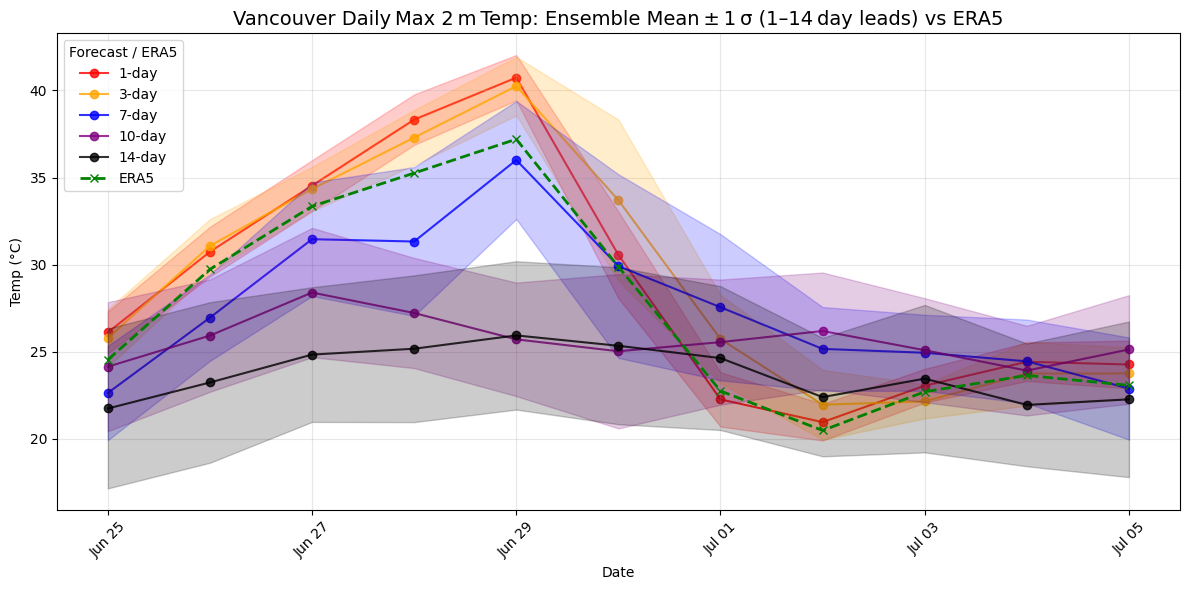

In [64]:
#!/usr/bin/env python3
# plot_vancouver_daily_max.py

import subprocess
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─── USER SETTINGS ────────────────────────────────────────────────────────────
START_DATE = "2021-06-25"
END_DATE   = "2021-07-05"
DATE_IDX   = pd.date_range(START_DATE, END_DATE, freq="D")

# Combined daily‐forecast CSVs on GCS
LEAD_FILES = {
    "1‑day":  "gs://gencast/daily_forecast_1day/vancouver_daily_forecast_1day.csv",
    "3‑day":  "gs://gencast/daily_forecast_3day/vancouver_daily_forecast_3day.csv",
    "7‑day":  "gs://gencast/daily_forecast_7day/vancouver_daily_forecast_7day.csv",
    "10‑day": "gs://gencast/daily_forecast_10day/vancouver_daily_forecast_10day.csv",
    "14‑day": "gs://gencast/daily_forecast_14day/vancouver_daily_forecast_14day.csv",
}

COLORS  = {"1‑day":"red","3‑day":"orange","7‑day":"blue","10‑day":"purple","14‑day":"black"}
ZORDERS = {"1‑day":1,"3‑day":2,"7‑day":3,"10‑day":4,"14‑day":5}

# Vancouver coords for ERA5
LAT_VAN = 49.2827
LON_VAN = -123.1207

# ─── STEP 1: FETCH & MERGE ERA5 ───────────────────────────────────────────────
# copy June & July files locally
for m in ("06","07"):
    src = f"gs://gencast/era5_new/2021-{m}-surface-level.nc"
    dst = f"/tmp/era5_2021-{m}.nc"
    subprocess.run(["gsutil","-q","cp", src, dst], check=True)

ds_june = xr.open_dataset("/tmp/era5_2021-06.nc", engine="netcdf4")
ds_july = xr.open_dataset("/tmp/era5_2021-07.nc", engine="netcdf4")

# drop any dummy 'time' dim
for ds in (ds_june, ds_july):
    if "time" in ds.dims:
        ds = ds.isel(time=0, drop=True)
    if ds is ds_june:
        ds_june = ds
    else:
        ds_july = ds

ds = xr.concat([ds_june, ds_july], dim="valid_time")

# extract 2 m temp at Vancouver, convert to °C
lon360 = LON_VAN % 360
da_v = ds["t2m"].sel(latitude=LAT_VAN, longitude=lon360, method="nearest") - 273.15

# build time series & compute daily max
ts = pd.Series(da_v.values, index=pd.to_datetime(ds.valid_time.values))
daily_era5 = (
    ts.groupby(ts.index.date)
      .max()
      .rename_axis("date")
      .reset_index(name="era5_max")
)
daily_era5["date"] = pd.to_datetime(daily_era5["date"])
daily_era5 = daily_era5[
    (daily_era5.date >= START_DATE) & (daily_era5.date <= END_DATE)
]

# ─── STEP 2: LOAD & AGGREGATE FORECAST CSVs ───────────────────────────────────
forecast_agg = {}
for tag, path in LEAD_FILES.items():
    df = pd.read_csv(
        path,
        storage_options={"token":"google_default"},
        parse_dates=["date"],
        dtype={"daily_max":"float"}
    )
    # ensure we really have a 'date' column
    if "date" not in df.columns:
        # fallback: assume first column is date
        df = df.rename(columns={df.columns[0]:"date"})
        df["date"] = pd.to_datetime(df["date"])
    df = df[(df.date >= START_DATE) & (df.date <= END_DATE)]
    # group
    g = df.groupby("date")["daily_max"].agg(mean="mean", std="std")
    # reindex full range & force 'date' column
    g = g.reindex(DATE_IDX)
    g = g.rename_axis("date").reset_index()
    forecast_agg[tag] = g

# ─── STEP 3: PLOT ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12,6))

for tag, g in forecast_agg.items():
    ax.plot(
        g["date"], g["mean"],
        color=COLORS[tag], marker="o",
        alpha=0.8, zorder=ZORDERS[tag],
        label=tag
    )
    ax.fill_between(
        g["date"],
        g["mean"] - g["std"],
        g["mean"] + g["std"],
        color=COLORS[tag], alpha=0.2,
        zorder=ZORDERS[tag]
    )

# ERA5 line
ax.plot(
    daily_era5["date"], daily_era5["era5_max"],
    color="green", linestyle="--", marker="x",
    linewidth=2, zorder=10, label="ERA5"
)

# decorate
ax.set_title(
    "Vancouver Daily Max 2 m Temp: Ensemble Mean ± 1 σ (1–14 day leads) vs ERA5",
    fontsize=14
)
ax.set_xlabel("Date"); ax.set_ylabel("Temp (°C)")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(title="Forecast / ERA5", loc="upper left")
plt.tight_layout()
plt.savefig("vancouver_daily_max_vs_era5.png", dpi=300)
plt.show()


In [71]:
#!/usr/bin/env python3
# plot_daily_vs_era5.py

import subprocess
from pathlib import Path

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─── USER SETTINGS ────────────────────────────────────────────────────────────
START_DATE = "2021-06-25"
END_DATE   = "2021-07-05"
DATE_IDX   = pd.date_range(START_DATE, END_DATE, freq="D")

LEADS      = [1, 3, 7, 10, 14]

ERA5_FILES = [
    "/tmp/era5_2021-06-surface.nc",
    "/tmp/era5_2021-07-surface.nc",
]

GCS_OPTS     = {"token": "google_default"}
FORECAST_FMT = "gs://gencast/daily_forecast_{lead}day/{loc}_daily_forecast_{lead}day.csv"

POINTS = {
    "vancouver": {"lat": 49.2827, "lon": -123.1207},
    "lytton":    {"lat": 50.2333, "lon": -121.7667},
}

COLORS     = {1:"red", 3:"orange", 7:"blue", 10:"purple", 14:"black"}
ZORDERS    = {1:1,    3:2,       7:3,       10:4,        14:5}
LEADS_TEXT = ", ".join(str(l) for l in LEADS[:-1]) + f", and {LEADS[-1]} Days"


# ─── STEP 1: LOAD & MERGE ERA5 ────────────────────────────────────────────────

# (uncomment to fetch if needed)
#for fn in ERA5_FILES:
#    src = f"gs://gencast/era5_new/{Path(fn).name}"
#    subprocess.run(["gsutil","-q","cp", src, fn], check=True)

parts = []
for fn in ERA5_FILES:
    ds = xr.open_dataset(fn, engine="netcdf4")
    if "time" in ds.dims:
        ds = ds.isel(time=0, drop=True)
    parts.append(ds)
ds = xr.concat(parts, dim="valid_time")

era5_daily = {}
for loc, coord in POINTS.items():
    lat, lon = coord["lat"], coord["lon"] % 360
    da = ds["t2m"].sel(latitude=lat, longitude=lon, method="nearest") - 273.15
    ts = pd.Series(da.values, index=pd.to_datetime(ds.valid_time.values))
    dmax  = ts.groupby(ts.index.date).max().reindex(DATE_IDX.date, fill_value=np.nan)
    dmean = ts.groupby(ts.index.date).mean().reindex(DATE_IDX.date, fill_value=np.nan)
    era5_daily[loc] = {
        "max":  pd.DataFrame({"date":DATE_IDX, "era5":dmax.values}),
        "mean":pd.DataFrame({"date":DATE_IDX, "era5":dmean.values}),
    }


# ─── STEP 2: LOAD FORECASTS & AGGREGATE ──────────────────────────────────────

forecast_stats = {loc:{lead:{"max":None,"mean":None} for lead in LEADS}
                  for loc in POINTS}

for loc in POINTS:
    for lead in LEADS:
        path = FORECAST_FMT.format(lead=lead, loc=loc)
        try:
            df = pd.read_csv(path,
                             storage_options=GCS_OPTS,
                             parse_dates=["date"])
        except Exception:
            print(f"⚠️  missing {lead}‑day @ {loc}")
            continue

        df = df[(df.date>=START_DATE)&(df.date<=END_DATE)]
        if df.empty:
            empty = pd.DataFrame({
                "date":DATE_IDX,
                "mean": np.nan,
                "std":  np.nan
            })
            forecast_stats[loc][lead]["max"]  = empty.copy()
            forecast_stats[loc][lead]["mean"] = empty.copy()
            continue

        gm = (
            df.groupby("date")["daily_max"]
              .agg(mean="mean", std="std")
              .reindex(DATE_IDX, fill_value=np.nan)
              .rename_axis("date")
              .reset_index()
        )
        ga = (
            df.groupby("date")["daily_avg"]
              .agg(mean="mean", std="std")
              .reindex(DATE_IDX, fill_value=np.nan)
              .rename_axis("date")
              .reset_index()
        )
        forecast_stats[loc][lead]["max"]  = gm
        forecast_stats[loc][lead]["mean"] = ga


# ─── STEP 3: PLOTTING ─────────────────────────────────────────────────────────

def plot_loc_metric(loc: str, metric: str):
    fig, ax = plt.subplots(figsize=(12,6))
    for lead in LEADS:
        df = forecast_stats[loc][lead][metric]
        if df is None: 
            continue
        y = df["mean"].to_numpy()
        if np.isnan(y).all(): 
            continue
        x   = df["date"].to_numpy()
        std = df["std"].to_numpy()

        ax.plot(x, y,
                color=COLORS[lead], marker="o",
                alpha=0.8, zorder=ZORDERS[lead],
                label=f"{lead}-day")
        ax.fill_between(x, y-std, y+std,
                        color=COLORS[lead], alpha=0.2,
                        zorder=ZORDERS[lead])

    # ERA5
    edf = era5_daily[loc][metric]
    x2  = edf["date"].to_numpy()
    y2  = edf["era5"].to_numpy()
    ax.plot(x2, y2,
            color="green", linestyle="--", marker="x",
            linewidth=2, zorder=10, label="ERA5")

    # Title & labels
    station = loc.capitalize() + " (BC)"
    met_txt = "Daily Maximum" if metric=="max" else "Daily Mean"
    title = (
        f"GenCast Forecasted {met_txt} Temp at {station}\n"
        f"(Ensemble Mean ± 1 SD; Lead Times: {LEADS_TEXT})\n"
        "with ERA5"
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Date");  ax.set_ylabel("Temperature (°C)")

    # ←── here’s the only change:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    plt.xticks(rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Lead Time / ERA5", loc="upper left")
    plt.tight_layout()

    outfn = f"{loc}_daily_{metric}_vs_era5.png"
    plt.savefig(outfn, dpi=300)
    print(f"✅ Saved {outfn}")
    plt.close()

for loc in POINTS:
    for metr in ("max","mean"):
        plot_loc_metric(loc, metr)


✅ Saved vancouver_daily_max_vs_era5.png
✅ Saved vancouver_daily_mean_vs_era5.png
✅ Saved lytton_daily_max_vs_era5.png
✅ Saved lytton_daily_mean_vs_era5.png


In [66]:
cd

/home/jupyter
